# Домашнее задание: RNN vs LSTM vs GRU

В этой работе сравниваются три рекуррентные архитектуры на простой синтетической задаче.

Модель получает последовательность цифр `x` и должна предсказать последовательность `y` такой же длины:

- `y1 = x1`;
- для остальных позиций `yi = (xi + x1) % 10`.

Главная идея: модель должна запомнить первый элемент последовательности `x1` и использовать его при обработке всех следующих элементов.

## Почему здесь нужна рекуррентная сеть

Правильный ответ в позиции `i` зависит не только от текущей цифры `x(i)`, но и от первой цифры последовательности `x(1)`. Значит, модели нужно сохранить информацию из начала последовательности и использовать ее позже.

Это хорошо демонстрирует смысл hidden state в RNN, LSTM и GRU: скрытое состояние переносит информацию от одного шага последовательности к следующему.

## 1. Импорты и reproducibility

In [3]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 2. Параметры эксперимента

Все три модели будут обучаться на одинаковых данных и с одинаковыми гиперпараметрами. Это нужно, чтобы сравнение относилось именно к архитектурам.

In [4]:
TRAIN_SIZE = 20000
VAL_SIZE = 3000
TEST_SIZE = 3000
SEQ_LEN = 20
TEST_LONG_SEQ_LEN = 50

BATCH_SIZE = 128
EMBEDDING_DIM = 16
HIDDEN_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

NUM_DIGITS = 10

## 3. Генерация выборки

Цифры генерируются случайно. Target `Y` строится только в функции генерации данных. Внутри моделей правило `(xi + x1) % 10` не используется.

In [5]:
def generate_data(num_sequences, seq_len):
    X = torch.randint(
        low=0,
        high=10,
        size=(num_sequences, seq_len),
        dtype=torch.long,
    )

    Y = torch.empty_like(X)
    Y[:, 0] = X[:, 0]
    Y[:, 1:] = (X[:, 1:] + X[:, 0:1]) % 10

    return X, Y


example_x = torch.tensor([[3, 5, 9, 1, 7]], dtype=torch.long)
example_y = torch.empty_like(example_x)
example_y[:, 0] = example_x[:, 0]
example_y[:, 1:] = (example_x[:, 1:] + example_x[:, 0:1]) % 10

print('Пример из условия')
print('x:', example_x[0].tolist())
print('y:', example_y[0].tolist())
assert example_y[0].tolist() == [3, 8, 2, 4, 0]
print('Проверка примера пройдена')

Пример из условия
x: [3, 5, 9, 1, 7]
y: [3, 8, 2, 4, 0]
Проверка примера пройдена


In [6]:
torch.manual_seed(SEED)
X_train, y_train = generate_data(TRAIN_SIZE, SEQ_LEN)
X_val, y_val = generate_data(VAL_SIZE, SEQ_LEN)
X_test, y_test = generate_data(TEST_SIZE, SEQ_LEN)

print('X_train shape:', tuple(X_train.shape))
print('y_train shape:', tuple(y_train.shape))
print('X dtype:', X_train.dtype)
print('Y dtype:', y_train.dtype)

print('\nНесколько примеров:')
for idx in range(5):
    print('X:', X_train[idx].tolist())
    print('Y:', y_train[idx].tolist())
    print()

# Программная проверка правила на случайной строке.
check_idx = 0
manual_y = y_train[check_idx].clone()
assert manual_y[0].item() == X_train[check_idx, 0].item()
assert torch.equal(manual_y[1:], (X_train[check_idx, 1:] + X_train[check_idx, 0]) % 10)
print('Проверка правила генерации данных пройдена')

X_train shape: (20000, 20)
y_train shape: (20000, 20)
X dtype: torch.int64
Y dtype: torch.int64

Несколько примеров:
X: [2, 7, 6, 4, 6, 5, 0, 4, 0, 3, 8, 4, 0, 4, 1, 2, 5, 5, 7, 6]
Y: [2, 9, 8, 6, 8, 7, 2, 6, 2, 5, 0, 6, 2, 6, 3, 4, 7, 7, 9, 8]

X: [9, 6, 3, 1, 9, 3, 1, 9, 7, 9, 2, 0, 5, 9, 3, 4, 9, 6, 2, 0]
Y: [9, 5, 2, 0, 8, 2, 0, 8, 6, 8, 1, 9, 4, 8, 2, 3, 8, 5, 1, 9]

X: [6, 2, 7, 9, 7, 3, 3, 4, 3, 7, 0, 9, 0, 9, 6, 9, 5, 4, 8, 8]
Y: [6, 8, 3, 5, 3, 9, 9, 0, 9, 3, 6, 5, 6, 5, 2, 5, 1, 0, 4, 4]

X: [6, 0, 0, 0, 0, 1, 3, 0, 1, 1, 7, 9, 4, 3, 8, 9, 3, 7, 8, 1]
Y: [6, 6, 6, 6, 6, 7, 9, 6, 7, 7, 3, 5, 0, 9, 4, 5, 9, 3, 4, 7]

X: [4, 1, 6, 3, 2, 0, 9, 8, 5, 3, 7, 7, 5, 9, 1, 5, 1, 9, 1, 4]
Y: [4, 5, 0, 7, 6, 4, 3, 2, 9, 7, 1, 1, 9, 3, 5, 9, 5, 3, 5, 8]

Проверка правила генерации данных пройдена


## 4. DataLoader

In [7]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print('Batch X:', tuple(batch_x.shape))
print('Batch Y:', tuple(batch_y.shape))

Batch X: (128, 20)
Batch Y: (128, 20)


## 5. Представление цифр

Цифры `0...9` являются категориями, поэтому используем `nn.Embedding`. После embedding вход имеет форму `[batch, seq_len, embedding_dim]`.

## 6. Модели RNN, LSTM и GRU

Все три модели имеют одинаковую внешнюю структуру:

`цифры → Embedding → RNN/LSTM/GRU → Linear → 10 logits для каждой позиции`.

Важно: используется выход рекуррентного слоя на каждом timestep, а не только последнее hidden state. Это many-to-many задача.

In [8]:
class RNNModel(nn.Module):
    def __init__(self, num_digits, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=num_digits, embedding_dim=embedding_dim)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, num_digits)

    def forward(self, x):
        x = self.embedding(x)
        out, hidden = self.rnn(x)
        logits = self.fc(out)
        return logits


class LSTMModel(nn.Module):
    def __init__(self, num_digits, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=num_digits, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, num_digits)

    def forward(self, x):
        x = self.embedding(x)
        out, (hidden, cell) = self.lstm(x)
        logits = self.fc(out)
        return logits


class GRUModel(nn.Module):
    def __init__(self, num_digits, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=num_digits, embedding_dim=embedding_dim)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, num_digits)

    def forward(self, x):
        x = self.embedding(x)
        out, hidden = self.gru(x)
        logits = self.fc(out)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

Проверим формы выходов до обучения.

In [9]:
for model_class in [RNNModel, LSTMModel, GRUModel]:
    model = model_class(NUM_DIGITS, EMBEDDING_DIM, HIDDEN_SIZE)
    logits = model(batch_x)
    print(model_class.__name__, 'logits shape:', tuple(logits.shape))
    assert logits.shape == (batch_x.size(0), SEQ_LEN, NUM_DIGITS)

print('Проверка размерностей пройдена')

RNNModel logits shape: (128, 20, 10)
LSTMModel logits shape: (128, 20, 10)
GRUModel logits shape: (128, 20, 10)
Проверка размерностей пройдена


## 7. Метрики и функция обучения

Считаем несколько метрик:

- token accuracy по всем позициям;
- sequence accuracy, где вся последовательность должна быть предсказана без ошибок;
- accuracy первой позиции;
- accuracy позиций `2..N`, где модели нужно использовать запомненный `x1`.

In [10]:
def compute_metrics_from_logits(logits, targets):
    preds = logits.argmax(dim=-1)

    correct = (preds == targets).sum().item()
    total = targets.numel()

    correct_sequences = (preds == targets).all(dim=1).sum().item()
    total_sequences = targets.size(0)

    first_correct = (preds[:, 0] == targets[:, 0]).sum().item()
    first_total = targets.size(0)

    tail_correct = (preds[:, 1:] == targets[:, 1:]).sum().item()
    tail_total = targets[:, 1:].numel()

    return {
        'correct': correct,
        'total': total,
        'correct_sequences': correct_sequences,
        'total_sequences': total_sequences,
        'first_correct': first_correct,
        'first_total': first_total,
        'tail_correct': tail_correct,
        'tail_total': tail_total,
    }


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_objects = 0
    metrics_sum = {
        'correct': 0,
        'total': 0,
        'correct_sequences': 0,
        'total_sequences': 0,
        'first_correct': 0,
        'first_total': 0,
        'tail_correct': 0,
        'tail_total': 0,
    }

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)
        loss = criterion(logits.reshape(-1, NUM_DIGITS), y_batch.reshape(-1))

        batch_size = x_batch.size(0)
        total_loss += loss.item() * batch_size
        total_objects += batch_size

        batch_metrics = compute_metrics_from_logits(logits, y_batch)
        for key, value in batch_metrics.items():
            metrics_sum[key] += value

    return {
        'loss': total_loss / total_objects,
        'accuracy': metrics_sum['correct'] / metrics_sum['total'],
        'sequence_accuracy': metrics_sum['correct_sequences'] / metrics_sum['total_sequences'],
        'accuracy_first_position': metrics_sum['first_correct'] / metrics_sum['first_total'],
        'accuracy_positions_2_to_n': metrics_sum['tail_correct'] / metrics_sum['tail_total'],
    }


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_sequence_acc': [],
        'val_acc_first_position': [],
        'val_acc_positions_2_to_n': [],
    }

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0.0
        total_objects = 0
        train_correct = 0
        train_total = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits.reshape(-1, NUM_DIGITS), y_batch.reshape(-1))
            loss.backward()
            optimizer.step()

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_objects += batch_size

            preds = logits.argmax(dim=-1)
            train_correct += (preds == y_batch).sum().item()
            train_total += y_batch.numel()

        train_loss = total_loss / total_objects
        train_acc = train_correct / train_total
        val_metrics = evaluate_model(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_sequence_acc'].append(val_metrics['sequence_accuracy'])
        history['val_acc_first_position'].append(val_metrics['accuracy_first_position'])
        history['val_acc_positions_2_to_n'].append(val_metrics['accuracy_positions_2_to_n'])

        print(
            f'Epoch {epoch:02d}/{num_epochs} | '
            f'Train loss: {train_loss:.4f} | '
            f'Val loss: {val_metrics["loss"]:.4f} | '
            f'Train accuracy: {train_acc:.2%} | '
            f'Val accuracy: {val_metrics["accuracy"]:.2%} | '
            f'Val sequence accuracy: {val_metrics["sequence_accuracy"]:.2%}'
        )

    return history

## 8. Обучение трех моделей

Для всех моделей используются одинаковые данные, размер embedding, hidden size, optimizer, learning rate, batch size и количество эпох.

In [11]:
def run_experiment(model_name, model_class):
    # Фиксируем seed перед созданием каждой модели, чтобы сравнение было воспроизводимым.
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = model_class(NUM_DIGITS, EMBEDDING_DIM, HIDDEN_SIZE).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print(f'\n=== {model_name} ===')
    print(model)
    print('Number of parameters:', count_parameters(model))

    start = time.time()
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
    )
    training_time = time.time() - start
    test_metrics = evaluate_model(model, test_loader, criterion, device)

    print(f'Test accuracy: {test_metrics["accuracy"]:.2%}')
    print(f'Test sequence accuracy: {test_metrics["sequence_accuracy"]:.2%}')
    print(f'Test acc positions 2..N: {test_metrics["accuracy_positions_2_to_n"]:.2%}')
    print(f'Training time: {training_time:.1f} sec')

    return {
        'model': model,
        'history': history,
        'test_metrics': test_metrics,
        'training_time': training_time,
        'number_of_parameters': count_parameters(model),
    }


experiments = {}
experiments['RNN'] = run_experiment('RNN', RNNModel)
experiments['LSTM'] = run_experiment('LSTM', LSTMModel)
experiments['GRU'] = run_experiment('GRU', GRUModel)


=== RNN ===
RNNModel(
  (embedding): Embedding(10, 16)
  (rnn): RNN(16, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)
Number of parameters: 6058
Epoch 01/10 | Train loss: 2.2929 | Val loss: 2.2697 | Train accuracy: 14.02% | Val accuracy: 16.02% | Val sequence accuracy: 0.60%
Epoch 02/10 | Train loss: 2.1901 | Val loss: 2.1248 | Train accuracy: 17.36% | Val accuracy: 20.26% | Val sequence accuracy: 9.17%
Epoch 03/10 | Train loss: 2.0609 | Val loss: 2.0191 | Train accuracy: 22.49% | Val accuracy: 22.60% | Val sequence accuracy: 8.97%
Epoch 04/10 | Train loss: 1.9877 | Val loss: 1.9828 | Train accuracy: 23.33% | Val accuracy: 22.84% | Val sequence accuracy: 9.17%
Epoch 05/10 | Train loss: 1.9596 | Val loss: 1.9627 | Train accuracy: 23.65% | Val accuracy: 23.43% | Val sequence accuracy: 9.17%
Epoch 06/10 | Train loss: 1.9405 | Val loss: 1.9449 | Train accuracy: 24.25% | Val accuracy: 23.85% | Val sequence accuracy: 9.17%
Epoch 07/10 | Train loss: 1.923

## 9. Графики

Сравним validation loss, validation accuracy и sequence accuracy.

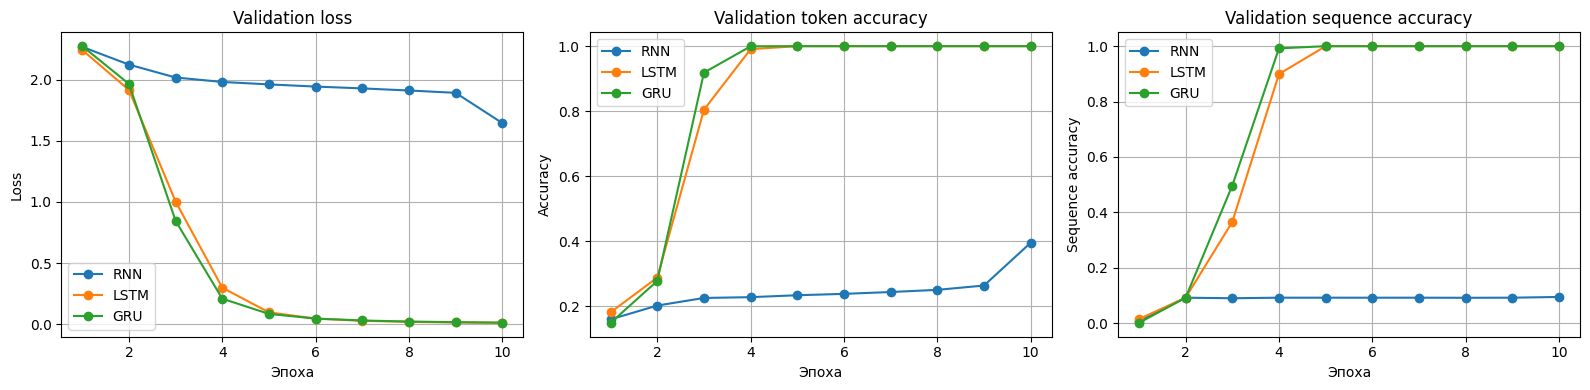

In [12]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
for model_name, result in experiments.items():
    plt.plot(epochs, result['history']['val_loss'], marker='o', label=model_name)
plt.title('Validation loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for model_name, result in experiments.items():
    plt.plot(epochs, result['history']['val_acc'], marker='o', label=model_name)
plt.title('Validation token accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
for model_name, result in experiments.items():
    plt.plot(epochs, result['history']['val_sequence_acc'], marker='o', label=model_name)
plt.title('Validation sequence accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Sequence accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 10. Итоговая таблица

Таблица формируется автоматически из истории обучения и тестовых метрик.

In [13]:
comparison_rows = []

for model_name, result in experiments.items():
    history = result['history']
    test_metrics = result['test_metrics']
    comparison_rows.append({
        'Model': model_name,
        'Best val accuracy': max(history['val_acc']),
        'Best val sequence accuracy': max(history['val_sequence_acc']),
        'Test accuracy': test_metrics['accuracy'],
        'Test sequence accuracy': test_metrics['sequence_accuracy'],
        'Test acc first position': test_metrics['accuracy_first_position'],
        'Test acc positions 2..N': test_metrics['accuracy_positions_2_to_n'],
        'Training time': result['training_time'],
        'Number of parameters': result['number_of_parameters'],
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Model,Best val accuracy,Best val sequence accuracy,Test accuracy,Test sequence accuracy,Test acc first position,Test acc positions 2..N,Training time,Number of parameters
0,RNN,0.395667,0.094333,0.378733,0.097333,1.0,0.346035,5.228625,6058
1,LSTM,1.000000,1.000000,0.999933,0.999667,1.0,0.999930,4.864204,21802
2,GRU,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,4.769446,16554


## 11. Проверка на конкретных примерах

Покажем первые 5 последовательностей из test dataset. Примеры не выбираются специально.

In [14]:
@torch.no_grad()
def predict_sequence(model, x_sequence):
    model.eval()
    x_tensor = x_sequence.unsqueeze(0).to(device)
    logits = model(x_tensor)
    return logits.argmax(dim=-1).squeeze(0).cpu()


for model_name, result in experiments.items():
    print(f'\n=== {model_name} ===')
    model = result['model']

    for idx in range(5):
        x_sequence = X_test[idx]
        target_sequence = y_test[idx]
        predicted_sequence = predict_sequence(model, x_sequence)
        is_correct = torch.equal(predicted_sequence, target_sequence)

        print('Input X:   ', x_sequence.tolist())
        print('Target Y:  ', target_sequence.tolist())
        print('Predicted: ', predicted_sequence.tolist())
        print('Correct:   ', is_correct)
        print()


=== RNN ===
Input X:    [6, 5, 3, 0, 6, 8, 1, 6, 6, 8, 2, 3, 6, 1, 1, 6, 5, 1, 0, 4]
Target Y:   [6, 1, 9, 6, 2, 4, 7, 2, 2, 4, 8, 9, 2, 7, 7, 2, 1, 7, 6, 0]
Predicted:  [6, 1, 6, 9, 3, 4, 4, 5, 5, 4, 5, 9, 3, 8, 8, 5, 4, 8, 2, 8]
Correct:    False

Input X:    [7, 5, 8, 7, 4, 8, 7, 9, 7, 4, 2, 6, 0, 2, 6, 9, 8, 8, 0, 5]
Target Y:   [7, 2, 5, 4, 1, 5, 4, 6, 4, 1, 9, 3, 7, 9, 3, 6, 5, 5, 7, 2]
Predicted:  [7, 8, 6, 0, 0, 7, 0, 2, 9, 8, 1, 5, 9, 5, 5, 2, 4, 4, 9, 4]
Correct:    False

Input X:    [1, 6, 1, 0, 8, 9, 1, 7, 9, 4, 4, 7, 9, 3, 7, 1, 6, 0, 0, 9]
Target Y:   [1, 7, 2, 1, 9, 0, 2, 8, 0, 5, 5, 8, 0, 4, 8, 2, 7, 1, 1, 0]
Predicted:  [1, 6, 6, 5, 3, 4, 2, 2, 4, 5, 5, 2, 4, 4, 2, 9, 1, 5, 5, 4]
Correct:    False

Input X:    [7, 6, 4, 2, 8, 7, 9, 8, 0, 1, 5, 8, 8, 8, 2, 7, 6, 9, 6, 9]
Target Y:   [7, 3, 1, 9, 5, 4, 6, 5, 7, 8, 2, 5, 5, 5, 9, 4, 3, 6, 3, 6]
Predicted:  [7, 6, 1, 5, 4, 0, 2, 4, 9, 4, 4, 7, 4, 4, 5, 0, 5, 2, 5, 2]
Correct:    False

Input X:    [1, 0, 2, 6, 5, 2, 0, 3

## 12. Дополнительный тест на более длинных последовательностях

Модели обучались на длине `SEQ_LEN = 20`. Проверим их без переобучения на последовательностях длины `TEST_LONG_SEQ_LEN = 50`. Основной интерес — accuracy на позициях `2..N`, где нужно помнить `x1`.

In [15]:
torch.manual_seed(SEED + 1)
X_long_test, y_long_test = generate_data(TEST_SIZE, TEST_LONG_SEQ_LEN)
long_test_loader = DataLoader(
    TensorDataset(X_long_test, y_long_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

criterion = nn.CrossEntropyLoss()
long_rows = []

for model_name, result in experiments.items():
    long_metrics = evaluate_model(result['model'], long_test_loader, criterion, device)
    long_rows.append({
        'Model': model_name,
        'Long test accuracy': long_metrics['accuracy'],
        'Long sequence accuracy': long_metrics['sequence_accuracy'],
        'Long acc first position': long_metrics['accuracy_first_position'],
        'Long acc positions 2..N': long_metrics['accuracy_positions_2_to_n'],
    })

long_test_df = pd.DataFrame(long_rows)
display(long_test_df)

,Model,Long test accuracy,Long sequence accuracy,Long acc first position,Long acc positions 2..N
0,RNN,0.337527,0.104667,1.0,0.324007
1,LSTM,0.999747,0.999333,1.0,0.999741
2,GRU,1.000000,1.000000,1.0,1.000000


## Чем отличаются RNN, LSTM и GRU

### RNN

Обычная RNN имеет hidden state и на каждом шаге обновляет его по текущему входу и прошлому состоянию: `h_t = f(x_t, h_(t-1))`. Проблема обычной RNN в том, что на длинных последовательностях ей может быть трудно сохранить информацию из далекого прошлого.

### LSTM

LSTM использует дополнительное состояние памяти и специальные gates: forget gate, input gate и output gate. Эти механизмы помогают решать, какую информацию забыть, какую добавить и какую передать дальше.

### GRU

GRU похожа на LSTM, но устроена проще. У нее меньше механизмов/gates, поэтому при одинаковом `hidden_size` она обычно имеет меньше параметров, чем LSTM, но больше, чем обычная RNN.

# Вывод

Следующая ячейка формирует итоговый вывод на основе фактически полученных результатов.

In [16]:
best_test_row = comparison_df.loc[comparison_df['Test accuracy'].idxmax()]
fastest_row = comparison_df.loc[comparison_df['Training time'].idxmin()]
best_long_row = long_test_df.loc[long_test_df['Long acc positions 2..N'].idxmax()]

rnn_row = comparison_df.loc[comparison_df['Model'] == 'RNN'].iloc[0]
lstm_row = comparison_df.loc[comparison_df['Model'] == 'LSTM'].iloc[0]
gru_row = comparison_df.loc[comparison_df['Model'] == 'GRU'].iloc[0]

rnn_long_row = long_test_df.loc[long_test_df['Model'] == 'RNN'].iloc[0]
lstm_long_row = long_test_df.loc[long_test_df['Model'] == 'LSTM'].iloc[0]
gru_long_row = long_test_df.loc[long_test_df['Model'] == 'GRU'].iloc[0]

conclusion = f'''
# Итоговый вывод

1. Обычная RNN на test dataset получила token accuracy **{rnn_row['Test accuracy']:.2%}**, sequence accuracy **{rnn_row['Test sequence accuracy']:.2%}** и accuracy на позициях `2..N` **{rnn_row['Test acc positions 2..N']:.2%}**.

2. LSTM получила token accuracy **{lstm_row['Test accuracy']:.2%}**, sequence accuracy **{lstm_row['Test sequence accuracy']:.2%}** и accuracy на позициях `2..N` **{lstm_row['Test acc positions 2..N']:.2%}**.

3. GRU получила token accuracy **{gru_row['Test accuracy']:.2%}**, sequence accuracy **{gru_row['Test sequence accuracy']:.2%}** и accuracy на позициях `2..N` **{gru_row['Test acc positions 2..N']:.2%}**.

4. Лучшее test accuracy показала модель **{best_test_row['Model']}**: **{best_test_row['Test accuracy']:.2%}**. Быстрее всего обучалась модель **{fastest_row['Model']}**: **{fastest_row['Training time']:.2f} секунд**.

5. Accuracy первой позиции показывает, насколько модель научилась копировать `x1`, потому что `y1 = x1`. Accuracy на позициях `2..N` важнее для этой задачи: там ответ зависит от текущей цифры и от первого элемента последовательности, который нужно сохранить в hidden state.

6. На длинной последовательности длины `{TEST_LONG_SEQ_LEN}` accuracy на позициях `2..N` получилась такой: RNN — **{rnn_long_row['Long acc positions 2..N']:.2%}**, LSTM — **{lstm_long_row['Long acc positions 2..N']:.2%}**, GRU — **{gru_long_row['Long acc positions 2..N']:.2%}**. Лучший результат на длинном тесте показала модель **{best_long_row['Model']}**.

7. Если на длинных последовательностях качество RNN ниже, чем у LSTM/GRU, это согласуется с теорией: LSTM и GRU лучше сохраняют долгосрочную информацию благодаря gating-механизмам. Если сильной разницы нет, значит для данной длины и объема обучения обычной RNN оказалось достаточно, чтобы запомнить первый элемент.

8. Все модели получали на вход только обычную последовательность `x1, x2, ..., xn`. Первый элемент не подавался отдельно на каждый timestep, а правильное правило использовалось только при генерации target `Y`, не внутри моделей.
'''

display(Markdown(conclusion))


# Итоговый вывод

1. Обычная RNN на test dataset получила token accuracy **37.87%**, sequence accuracy **9.73%** и accuracy на позициях `2..N` **34.60%**.

2. LSTM получила token accuracy **99.99%**, sequence accuracy **99.97%** и accuracy на позициях `2..N` **99.99%**.

3. GRU получила token accuracy **100.00%**, sequence accuracy **100.00%** и accuracy на позициях `2..N` **100.00%**.

4. Лучшее test accuracy показала модель **GRU**: **100.00%**. Быстрее всего обучалась модель **GRU**: **4.77 секунд**.

5. Accuracy первой позиции показывает, насколько модель научилась копировать `x1`, потому что `y1 = x1`. Accuracy на позициях `2..N` важнее для этой задачи: там ответ зависит от текущей цифры и от первого элемента последовательности, который нужно сохранить в hidden state.

6. На длинной последовательности длины `50` accuracy на позициях `2..N` получилась такой: RNN — **32.40%**, LSTM — **99.97%**, GRU — **100.00%**. Лучший результат на длинном тесте показала модель **GRU**.

7. Если на длинных последовательностях качество RNN ниже, чем у LSTM/GRU, это согласуется с теорией: LSTM и GRU лучше сохраняют долгосрочную информацию благодаря gating-механизмам. Если сильной разницы нет, значит для данной длины и объема обучения обычной RNN оказалось достаточно, чтобы запомнить первый элемент.

8. Все модели получали на вход только обычную последовательность `x1, x2, ..., xn`. Первый элемент не подавался отдельно на каждый timestep, а правильное правило использовалось только при генерации target `Y`, не внутри моделей.
